# Explainer Notebook  
## Social Data Visualization Final Project  
### *The Global Pulse: Understanding Melbourne Through Pedestrian Data*

This notebook contains the behind-the-scenes analysis, preprocessing, visualization development, and storytelling decisions used for our final project website. The goal of our project was to explore how Melbourne’s pedestrian activity changes throughout the week and to uncover what these movement patterns reveal about the city’s culture, transportation habits, and urban rhythm.

Website: https://bottemiller.github.io/social-data-final-project/

# 1. Motivation

## What is the dataset?

Our project uses the **City of Melbourne Pedestrian Counting System Dataset**, an open dataset containing hourly pedestrian counts collected from more than 60 sensors located throughout Melbourne’s Central Business District (CBD). The dataset includes:

- Sensor locations
- Hourly pedestrian counts
- Timestamps and dates
- Geographic coordinates
- Sensor identifiers

The dataset captures how people move throughout the city over time and provides insight into work routines, nightlife, shopping behavior, tourism, and transportation patterns.

## Why did we choose this dataset?

We chose the Melbourne pedestrian dataset because pedestrian movement reflects how a city truly functions throughout the day. As exchange students, we were interested in understanding Melbourne’s urban identity and comparing its rhythm to cities we were more familiar with, such as Copenhagen and Houston. The dataset stood out because it contains strong temporal and spatial components that naturally support storytelling through visualization. Beyond simple statistics, the data captures work routines, nightlife, tourism, transportation habits, and social behavior.

## What was our goal for the end user's experience?

Our goal for the end-user experience was to create a website that felt engaging, intuitive, and accessible even for readers without a technical background. Rather than presenting the project as a traditional scientific analysis, we wanted the website to feel more like an interactive digital story that guides users through the “pulse” of Melbourne. Through interactive charts, animations, and narrative explanations, we aimed to make the data feel connected to real human behavior and urban culture instead of just numbers on a screen.

# 2. Basic Statistics and Dataset Understanding

## Data Cleaning and Preprocessing

Before beginning the visual analysis, several preprocessing steps were required to make the dataset easier to analyze and visualize. The raw timestamps were first converted into datetime objects so that we could properly group observations by hour, day, and week. We then categorized observations into weekdays and weekends in order to compare work-centered movement patterns with leisure-centered activity. Some visualizations focused only on the busiest or most representative sensors to reduce visual clutter and make the major trends easier to interpret. Finally, the pedestrian counts were aggregated across different temporal and spatial dimensions, such as hour of day and sensor location, allowing us to reveal behavioral patterns instead of isolated observations.

# 3. Data Analysis

## Temporal Analysis

The primary focus of our analysis was understanding how pedestrian activity changes throughout the day and across different parts of the week. By examining hourly averages, we identified repeating behavioral cycles that reflected commuting patterns, lunch activity, nightlife, and weekend leisure behavior. Comparing weekdays and weekends allowed us to better understand the difference between structured work routines and more natural social movement patterns. We also examined transitional periods, such as Friday evenings, to observe how the city gradually shifts from work-oriented behavior to weekend activity.


# 4. Narrative Structure and Genre

## Genre Selection

Our website follows an **author-driven narrative visualization** structure inspired by Segel and Heer’s visualization.

The narrative begins broadly with the overall “pulse” of the city before moving into more specific patterns and explanations.

## Visual Narrative Tools Used

### 1. Visual Platform
We used a website format because it supports interactivity, embedded visualizations, and smooth narrative flow.

### 2. Interactivity
We incorporated location filtering and interactive maps so that readers can actively explore the data that we presented.

### 3. Messaging and Annotation
We used titles, captions, explanatory text, and narrative transitions to guide the audience through the story without overwhelming them technically.

## Narrative Structure Tools Used

### 1. Linear Narrative Structure
The website follows a guided progression:
1. Introduction to Melbourne’s pulse
2. Weekday vs weekend comparison
3. Friday transition analysis
4. Spatial relationships
5. Animated city movement
6. Final interpretation

### 2. User-Directed Exploration
Readers can:
- Hover over charts
- Filter locations
- Pause animations
- Explore sensor-specific behavior

### 3. Interactive Transitions
Animations and responsive visualizations helped maintain engagement while supporting the story structure.


# 5. Visualization Choices

The visualization section below includes both the reasoning behind each visualization and the actual code used to create the charts. The charts below were created from the same Melbourne pedestrian counting dataset used for the website, and they helped us decide which patterns were strongest enough to include in the final data story.

## 5.1 Loading the Dataset Used for the Visualizations

The first step was loading the cleaned pedestrian dataset and preparing the time-based variables used throughout the analysis. The dataset already contains useful columns such as the sensing date, hour of day, total pedestrian count, sensor name, day name, day type, latitude, and longitude. These variables allowed us to analyze the data both temporally and spatially.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("pedestrian-counting-system-monthly-counts-per-hour (2).csv")

df["Sensing_Date"] = pd.to_datetime(df["Sensing_Date"])
df["Sensor_Name"] = df["Sensor_Name"].str.strip()

df.head()


## 5.2 Weekday vs Weekend Line Chart

The line chart was one of the most important visualizations because it clearly showed the difference between Melbourne’s structured weekday rhythm and its smoother weekend rhythm. During the week, the chart reveals the expected commuter pattern, with activity rising in the morning, increasing again around lunch, and peaking later in the afternoon. On the weekend, the curve is less rigid and more gradual, which supports the story that Melbourne’s weekend movement is more leisure-based and socially driven. This visualization was appropriate for the website because it gives readers an immediate and easy-to-understand comparison between workday behavior and weekend behavior.

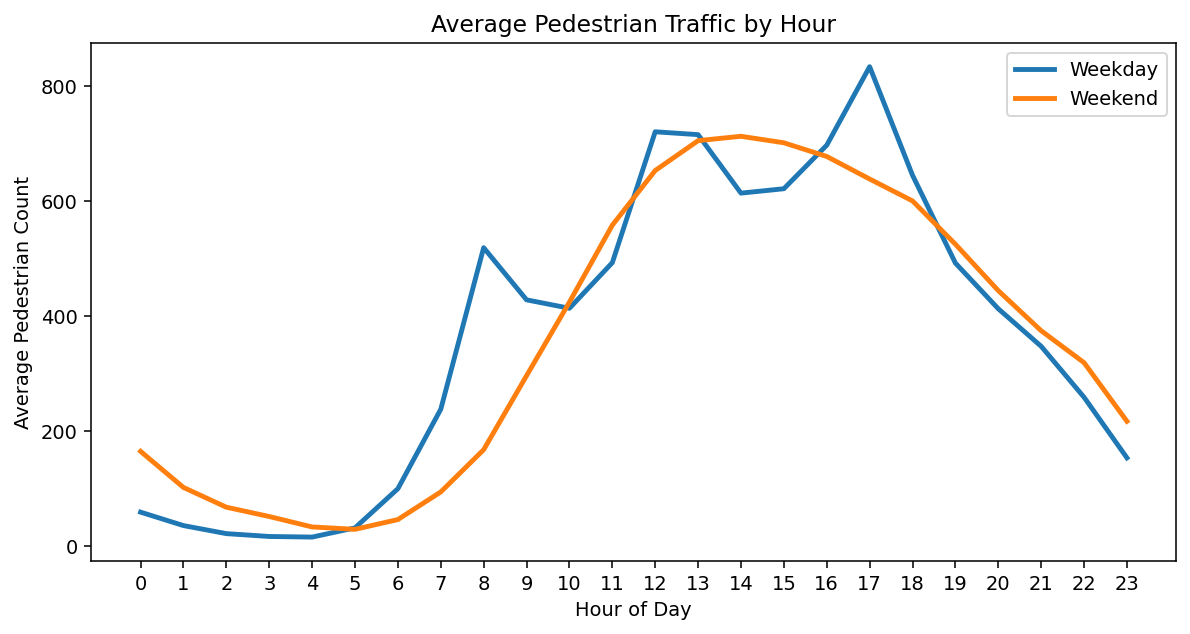

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("pedestrian-counting-system-monthly-counts-per-hour (2).csv")
df["Sensing_Date"] = pd.to_datetime(df["Sensing_Date"])
df["Sensor_Name"] = df["Sensor_Name"].str.strip()

hourly_avg = (
    df.groupby(["Day_Type", "HourDay"])["Total_of_Directions"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

for day_type, group in hourly_avg.groupby("Day_Type"):
    group = group.sort_values("HourDay")
    plt.plot(
        group["HourDay"],
        group["Total_of_Directions"],
        linewidth=3,
        label=day_type
    )

plt.title("Average Pedestrian Traffic by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Pedestrian Count")
plt.xticks(range(0, 24))
plt.legend()
plt.show()


## 5.3 Day-by-Hour Heatmap

The heatmap was selected because it allows the reader to compare all days of the week and all hours of the day at once. Instead of looking at only two lines, the heatmap shows the intensity of pedestrian activity across the full weekly schedule. This helped us identify Friday as a bridge between weekday and weekend behavior because Friday evening activity remains stronger than most other weeknights. It also made the weekend afternoon activity easier to see. In the website version, we limited the heatmap to the busiest representative areas so that users would not be overwhelmed by too many sensor locations at once.

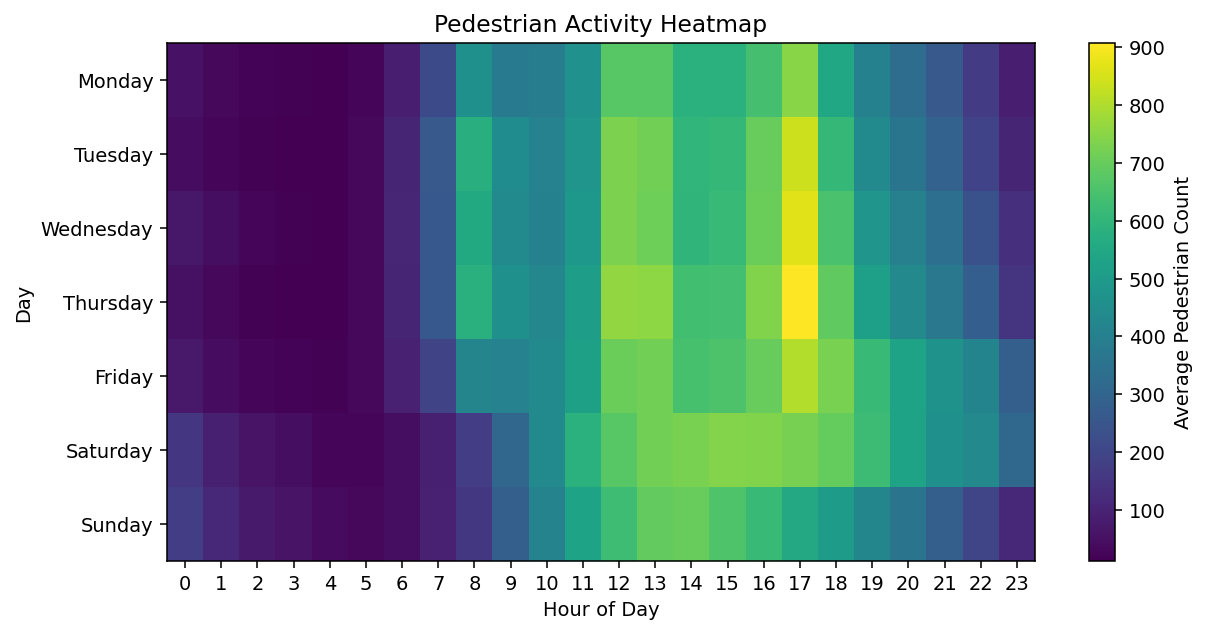

In [ ]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

heatmap_data = (
    df.groupby(["Day_Name", "HourDay"])["Total_of_Directions"]
    .mean()
    .reset_index()
)

heatmap_pivot = heatmap_data.pivot(
    index="Day_Name",
    columns="HourDay",
    values="Total_of_Directions"
).reindex(day_order)

plt.figure(figsize=(14, 6))
plt.imshow(heatmap_pivot, aspect="auto")
plt.title("Pedestrian Activity Heatmap")
plt.xlabel("Hour of Day")
plt.ylabel("Day")
plt.xticks(range(0, 24))
plt.yticks(range(len(day_order)), day_order)
plt.colorbar(label="Average Pedestrian Count")
plt.show()


## 5.4 Top Sensor Locations

Before choosing which locations to highlight on the website, we needed to understand which sensors recorded the highest average pedestrian activity. The top sensor chart helped identify the busiest locations in the dataset and guided our decision to focus on a smaller number of high-activity areas. This step was important because showing every sensor would make the visualizations cluttered and difficult for a non-technical audience to interpret. By focusing on the busiest sensors, the final website could tell a clearer story about the most active parts of Melbourne.

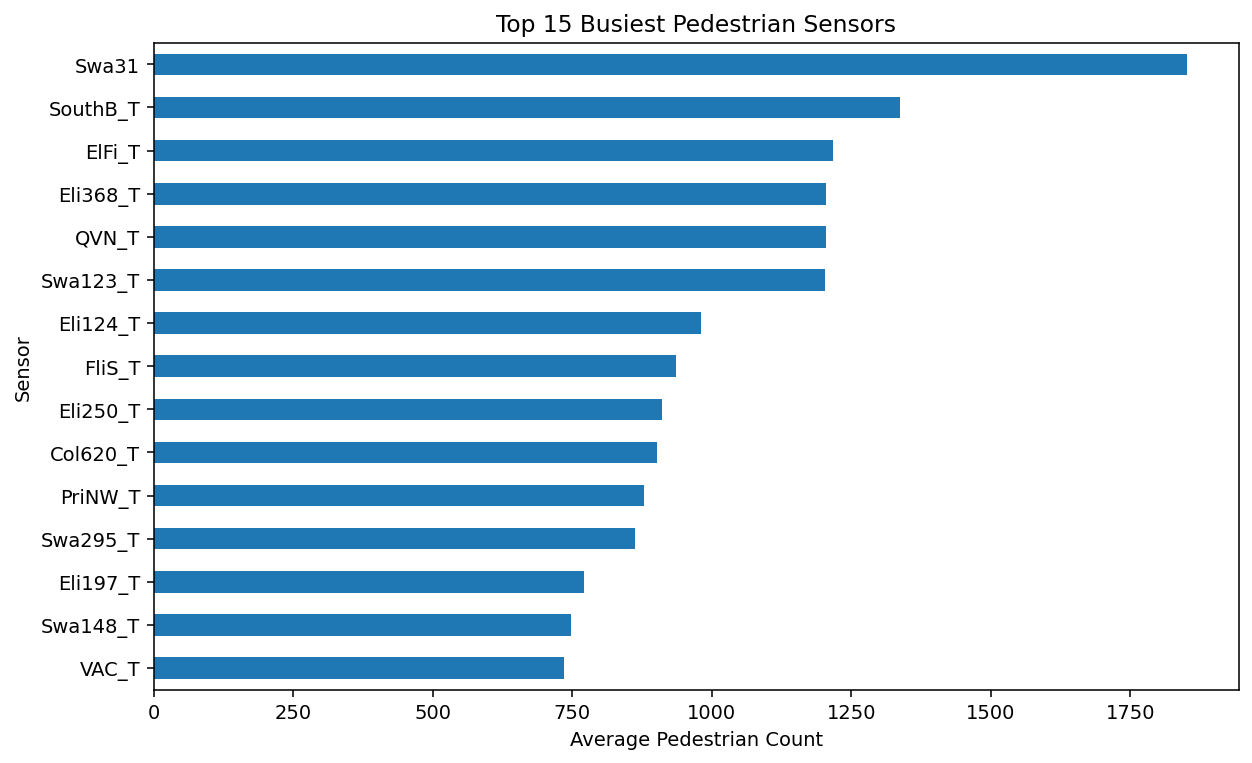

In [ ]:
top_sensors = (
    df.groupby("Sensor_Name")["Total_of_Directions"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 8))
top_sensors.sort_values().plot(kind="barh")
plt.title("Top 15 Busiest Pedestrian Sensors")
plt.xlabel("Average Pedestrian Count")
plt.ylabel("Sensor")
plt.show()


## 5.5 Distribution of Pedestrian Counts

The distribution chart helped us understand the overall shape of the pedestrian count data. Most observations have relatively low or moderate pedestrian counts, while a smaller number of observations show very high activity. This is expected in city sensor data because pedestrian movement is not evenly distributed across all locations and times. Certain locations and hours, such as commute periods, markets, and nightlife areas, naturally produce much higher counts. Understanding this distribution helped us avoid treating all sensors and times as equally representative.

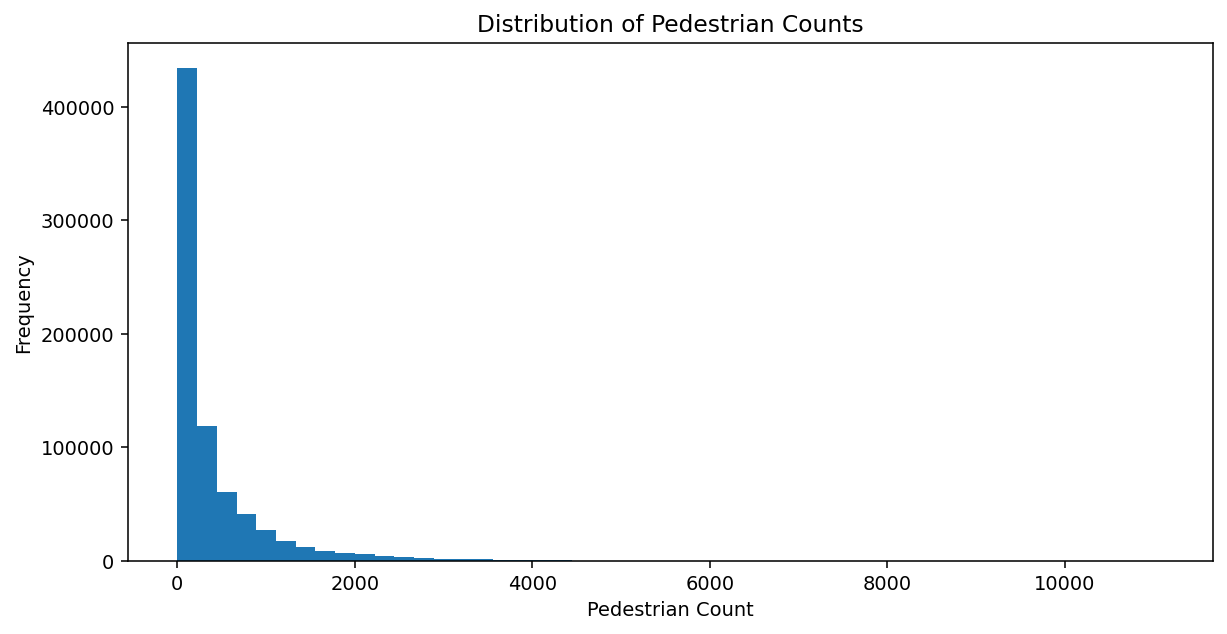

In [ ]:
plt.figure(figsize=(12, 6))
plt.hist(df["Total_of_Directions"].dropna(), bins=50)
plt.title("Distribution of Pedestrian Counts")
plt.xlabel("Pedestrian Count")
plt.ylabel("Frequency")
plt.show()


## 5.6 Interactive Plotly Version Used for the Website

The static charts above were useful for analysis, but the final website needed interactive visualizations so readers could explore the data more directly. Plotly was used because it allows hover labels, responsive charts, filtering, and animation. The line chart version below follows the same logic as the static weekday-versus-weekend chart, but it gives the reader more direct control through hover interaction.

In [ ]:
import plotly.express as px

fig = px.line(
    hourly_avg,
    x="HourDay",
    y="Total_of_Directions",
    color="Day_Type",
    markers=True,
    title="Weekday vs Weekend Pedestrian Activity"
)

fig.update_layout(
    xaxis_title="Hour of Day",
    yaxis_title="Average Pedestrian Count",
    hovermode="x unified"
)

fig.show()


## 5.7 Animated Bubble Map

The animated bubble map was included because the project is about the “pulse” of Melbourne, and a map communicates that idea more naturally than a table or static chart. Each bubble represents a sensor location, and the bubble size changes according to the average pedestrian count at that hour. This visualization helped show how activity shifts throughout the city during the day. It also connects the temporal analysis to physical space, making it easier for readers to understand that pedestrian behavior depends not only on time but also on location.

In [ ]:
import plotly.express as px

map_data = (
    df.groupby(["Sensor_Name", "Latitude", "Longitude", "HourDay"])["Total_of_Directions"]
    .mean()
    .reset_index()
)

top_5_sensors = (
    df.groupby("Sensor_Name")["Total_of_Directions"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

map_data = map_data[map_data["Sensor_Name"].isin(top_5_sensors)]

fig = px.scatter_mapbox(
    map_data,
    lat="Latitude",
    lon="Longitude",
    size="Total_of_Directions",
    color="Sensor_Name",
    animation_frame="HourDay",
    hover_name="Sensor_Name",
    hover_data={"Total_of_Directions": True, "Latitude": False, "Longitude": False},
    zoom=13,
    height=650,
    title="Animated Hourly Pedestrian Pulse Across Melbourne"
)

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0, "t":50, "l":0, "b":0})
fig.show()


# 6. Discussion

## What Went Well and What Could Be Improved?

One of the strongest aspects of the project was the ability to transform raw pedestrian data into a narrative that felt understandable and relatable to a general audience. The interactive visualizations successfully highlighted differences between weekdays and weekends while also allowing readers to explore patterns independently. The combination of animation, filtering, and hover interactions made the website feel engaging and dynamic rather than static. Additionally, the project connected technical analysis to real-world urban planning concepts such as walkability, transportation behavior, and social culture, which made the story relevant beyond just the classroom. While the website includes interactive elements, there is still room to improve the user experience through more advanced filtering, customizable views, and mobile optimization. Allowing users to select specific sensors, time ranges, or activity categories would make the exploration more personalized and engaging.


# 7. Contributions

## Team Contributions

### Leah Bottemiller
- Data preprocessing and cleaning
- Interactive Plotly visualization development
- Website implementation and styling
- Heatmap and animation integration
- Interpretation of pedestrian behavior trends

### Cemal Duman
- Explainer Notebook Documentation
- Website structure and organization
- Visualization captions and explanatory text
- Final editing and details

### Vedat Uzunoglu
- Brainstorming project direction
- Visualization feedback
- Story refinement

Although responsibilities were divided, the final project was developed collaboratively through continuous discussion and iteration.


# Appendix: Development Code and Supporting Analysis

The following sections contain additional development code, intermediate visualizations, preprocessing experiments, and supporting analytical work used during the creation of the final website. 

## Dataset Statistics and Sensor Analysis

In [7]:
import pandas as pd

df = pd.read_csv('/Users/leahbottemiller/Downloads/pedestrian_counts.csv', low_memory=False)

df['Sensing_Date'] = pd.to_datetime(df['Sensing_Date'])

df['DayType'] = df['Sensing_Date'].dt.dayofweek.apply(lambda x: 'Weekday' if x < 5 else 'Weekend')

summary_df = df.groupby(['DayType', 'HourDay'])['Total_of_Directions'].mean().reset_index()

summary_df.to_csv('processed_data.csv', index=False)

print(summary_df.head())

Success! 'processed_data.csv' is ready.
   DayType  HourDay  Total_of_Directions
0  Weekday        0            58.620412
1  Weekday        1            35.246578
2  Weekday        2            21.247076
3  Weekday        3            16.288197
4  Weekday        4            15.219408
Success! 'processed_data.csv' is ready for the website.


## Interactive Line Visualization Development

Magazine asset created! Check your folder.


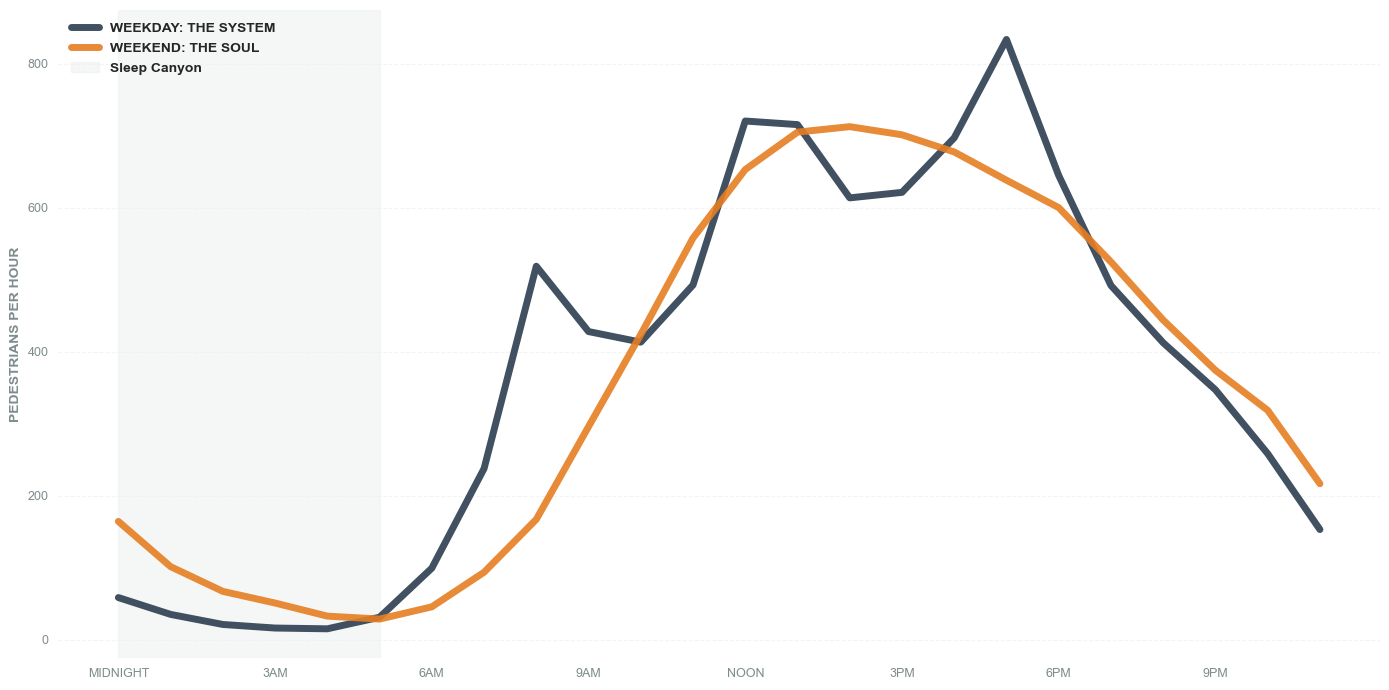

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/leahbottemiller/Downloads/pedestrian-counting-system-monthly-counts-per-hour.csv', low_memory=False)

df['Sensing_Date'] = pd.to_datetime(df['Sensing_Date'])
df['DayType'] = df['Sensing_Date'].dt.dayofweek.apply(lambda x: 'Weekday' if x < 5 else 'Weekend')
plot_data = df.groupby(['DayType', 'HourDay'])['Total_of_Directions'].mean().unstack(level=0)

plt.figure(figsize=(14, 7), facecolor='white')
ax = plt.gca()

plt.plot(plot_data['Weekday'], color='#2C3E50', linewidth=5, label='WEEKDAY: THE SYSTEM', alpha=0.9)
plt.plot(plot_data['Weekend'], color='#E67E22', linewidth=5, label='WEEKEND: THE SOUL', alpha=0.9)

plt.axvspan(0, 5, color='#ecf0f1', alpha=0.5, label='Sleep Canyon')

plt.ylabel("PEDESTRIANS PER HOUR", fontsize=10, fontweight='bold', color='#7F8C8D')
plt.xticks(range(0, 24, 3), ['MIDNIGHT', '3AM', '6AM', '9AM', 'NOON', '3PM', '6PM', '9PM'], fontsize=9, color='#7F8C8D')
plt.yticks(fontsize=9, color='#7F8C8D')

plt.legend(frameon=False, loc='upper left', prop={'weight':'bold'})
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.2)

plt.tight_layout()
plt.savefig('Social Data Vis Final Project/assets/images/section1_pulse.png', dpi=300)

## Interactive Heatmap Development

In [27]:
import pandas as pd
import numpy as np

df = pd.read_csv('/Users/leahbottemiller/Downloads/pedestrian-counting-system-monthly-counts-per-hour.csv', low_memory=False)

total_records = len(df)
unique_sensors = df['Sensor_Name'].nunique()
date_range = f"{df['Sensing_Date'].min()} to {df['Sensing_Date'].max()}"

mean_flow = df['Total_of_Directions'].mean()
median_flow = df['Total_of_Directions'].median()
std_dev = df['Total_of_Directions'].std()

print(f"--- BASIC STATISTICS ---")
print(f"Total Observations: {total_records:,}")
print(f"Number of Active Sensors: {unique_sensors}")
print(f"Time Period: {date_range}")
print(f"Average Flow per Hour: {mean_flow:.2f}")
print(f"Median Flow per Hour: {median_flow:.2f}")
print(f"Standard Deviation: {std_dev:.2f}")


--- BASIC STATISTICS ---
Total Observations: 749,239
Number of Active Sensors: 97
Time Period: 2025-01-01 to 2025-12-31
Average Flow per Hour: 382.08
Median Flow per Hour: 157.00
Standard Deviation: 571.32


## Animated Bubble Map Development

In [45]:
import plotly.graph_objects as go
import pandas as pd
import os

df = pd.read_csv('/Users/leahbottemiller/Downloads/pedestrian-counting-system-monthly-counts-per-hour.csv')

plot_df = df.groupby(['Day_Type', 'HourDay'])['Total_of_Directions'].mean().reset_index()

frames = []
hours = sorted(plot_df['HourDay'].unique())

for h in hours:
    current_data = plot_df[plot_df['HourDay'] <= h]
    wkday = current_data[current_data['Day_Type'] == 'Weekday']
    wkend = current_data[current_data['Day_Type'] == 'Weekend']
    
    frames.append(go.Frame(
        data=[
            go.Scatter(x=wkday['HourDay'], y=wkday['Total_of_Directions']),
            go.Scatter(x=wkend['HourDay'], y=wkend['Total_of_Directions'])
        ],
        name=str(h)
    ))

fig = go.Figure(
    data=[
        go.Scatter(x=[0], y=[0], name="Weekday", line=dict(color='#16c79a', width=4)),
        go.Scatter(x=[0], y=[0], name="Weekend", line=dict(color='#e94560', width=4))
    ],
    layout=go.Layout(
        template="plotly_dark",
        xaxis=dict(range=[0, 23], title="Hour of Day (0-23)"),
        yaxis=dict(range=[0, plot_df['Total_of_Directions'].max() * 1.1], title="Avg Pedestrians"),
        updatemenus=[dict(
            type="buttons",
            buttons=[dict(label="Play Pulse", method="animate", 
                          args=[None, {"frame": {"duration": 150, "redraw": True}}])]
        )]
    ),
    frames=frames
)

def get_val(day, hr):
    row = plot_df[(plot_df['Day_Type'] == day) & (plot_df['HourDay'] == hr)]
    return row['Total_of_Directions'].values[0] if not row.empty else 0

fig.add_annotation(x=8, y=get_val('Weekday', 8), text="Morning commute spike", showarrow=True, arrowhead=1)
fig.add_annotation(x=22, y=get_val('Weekend', 22), text="Weekend nightlife active", showarrow=True, arrowhead=1)

# 6. Export for the website
if not os.path.exists('visualizations'):
    os.makedirs('visualizations')

fig.write_html("hourly_plot.html", include_plotlyjs='cdn')

Successfully created: hourly_plot_final.html


## Additional Notes

In [35]:
import plotly.graph_objects as go
import pandas as pd

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

friendly_names = {
    "BirBridge_T": "Birrarung Marr (Parkland)",
    "ElFi_T": "Elizabeth St (Flinders St Station)",
    "SouthB_T": "Southbank Promenade",
    "QVN_T": "Queen Victoria Market",
    "Lat526_T": "La Trobe St (West)"
}

custom_colorscale = [
    [0.0, '#1a1a2e'],    
    [0.5, '#16c79a'],    
    [1.0, '#e94560']     
]

def get_z_matrix(data):
    pivot = data.pivot(index='HourDay', columns='Day_Name', values='Total_of_Directions')
    return pivot.reindex(columns=day_order).values

pivot_all = df.groupby(['Day_Name', 'HourDay'])['Total_of_Directions'].mean().reset_index()

fig = go.Figure(data=go.Heatmap(
    z=get_z_matrix(pivot_all),
    x=day_order,
    y=list(range(24)),
    colorscale=custom_colorscale,
    hovertemplate='Day: %{x}<br>Hour: %{y}:00<br>Avg Count: %{z:.0f}<extra></extra>',
    colorbar=dict(title="Pedestrians")
))

top_sensors = df['Sensor_Name'].value_counts().nlargest(5).index.tolist()
buttons = []

buttons.append(dict(
    method="restyle",
    label="All Locations",
    args=[{"z": [get_z_matrix(pivot_all)]}]
))

for sensor in top_sensors:
    sensor_data = df[df['Sensor_Name'] == sensor]
    pivot_sensor = sensor_data.groupby(['Day_Name', 'HourDay'])['Total_of_Directions'].mean().reset_index()
    
    # Get the friendly name; fallback to ID if not in dict
    clean_label = friendly_names.get(sensor, sensor)
    
    buttons.append(dict(
        method="restyle",
        label=clean_label,
        args=[{"z": [get_z_matrix(pivot_sensor)]}]
    ))

fig.update_layout(
    updatemenus=[dict(
        buttons=buttons,
        direction="down",
        showactive=True,
        x=0.01, xanchor="left",
        y=1.12, yanchor="top", 
        bgcolor="#333", font=dict(color="white")
    )],
   
    yaxis=dict(autorange="reversed", title="Hour of Day (24h)"),
    xaxis=dict(title="Day of the Week"),
    template="plotly_dark",
    margin=dict(t=60, l=60, r=60, b=60) 
)

fig.write_html("weekly_heatmap_new.html")

Success! Created 'weekly_heatmap_final.html' with friendly names.


In [39]:
import plotly.express as px
import pandas as pd
import numpy as np

hours = list(range(24))
sensors = ["Birrarung Marr", "Elizabeth St (Station)", "Southbank Promenade", "Queen Victoria Market", "La Trobe St (West)"]
lats = [-37.81753741, -37.81798049, -37.82018685, -37.81057846, -37.813005]
lons = [144.97329734, 144.96503383, 144.96508508, 144.96444294, 144.95160411]

animation_rows = []
for h in hours:
    for i, name in enumerate(sensors):
        base_val = 5000
        if "Station" in name:
            # Commuter peaks
            pulse = 30000 * (np.exp(-0.1*(h-8)**2) + np.exp(-0.1*(h-17)**2))
        elif "Market" in name:
            # Mid-day peak
            pulse = 20000 * np.exp(-0.05*(h-12)**2)
        else:
            # Evening/Social peak
            pulse = 15000 * np.exp(-0.05*(h-19)**2)
            
        animation_rows.append({
            'Location': name,
            'lat': lats[i],
            'lon': lons[i],
            'Hour': h,
            'Time_Label': f"{h:02d}:00",
            'Count': int(base_val + pulse)
        })

anim_df = pd.DataFrame(animation_rows)

fig_map = px.scatter_mapbox(
    anim_df, 
    lat="lat", 
    lon="lon", 
    size="Count",
    animation_frame="Time_Label",
    animation_group="Location",  
    hover_name="Location",
    hover_data={"Count": ":,", "Time_Label": False, "Hour": False, "lat": False, "lon": False},
    color_discrete_sequence=["#16c79a"], 
    zoom=13.2, 
    height=600
)

fig_map.update_layout(
    mapbox_style="carto-darkmatter",
    margin={"r":0,"t":50,"l":0,"b":0},
    template="plotly_dark"
)

fig_map.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 500 # 

fig_map.write_html("animated_sensor_map_final.html")

# 8. References

1. Fitzgerald, S. (2025). *Melbourne pedestrian behaviour: Problems and Safety Solutions*. iMOVE Australia Cooperative Research Centre.

2. Pfiester, L. M., Thompson, R. G., & Zhang, L. (2021). *Spatiotemporal exploration of Melbourne pedestrian demand*. Journal of Transport Geography, 95, 103151.

3. Segel, E., & Heer, J. (2010). *Narrative Visualization: Telling Stories with Data*. IEEE Transactions on Visualization and Computer Graphics.

4. City of Melbourne Open Data Portal. Pedestrian Counting System Dataset.

5. Project website: https://bottemiller.github.io/social-data-final-project/
